# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is linear if it is linear in the parameters. If the coeffeicients are multipliers in a sum, the model is linear. 

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

A dummy/one-hot-encoded variable coefficient is the difference in the outcome between the reference group and specified group. It tells you how much lower or higher the target group is from the reference. 

3. Can linear regression be used for classification? Explain why, or why not.

It is possible to use it for classification, but you shouldn't use it because it predicts continueous values instead of discrete catefories, so it doesn't give you the proper probability range of 0-1. Also it is very sensitive to outliers and create a relationship that does not fir with the data. 

4. What are signs that your linear model is over-fitting?

The biggest signs is that the model performs badly on test data, despite doing well on the training data. Also really large coefficients are usually a sign of over-fitting. 

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multi-colinearity is when multiple independent variables/predictors are highly correlated with each other. THis often appears in the first stage. So if the variables are correlataed with other controls, the predicted x won't have enough variation. So this leads to many errors in the second stage. 

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

You can add exponents to variable terms or use log transformations. 

7. What is the interpretation of the slope coefficient in a linear regression?

It is the average change in y for every single one-unit increase of x. 

8. Compare the train/test split and $k$-fold cross validation.

A train/test split is much faster, but there can be a bias in the results depending on how good the split is. k-fold cross validation takes much longer because it splits the data into k number of subsets an trains the data multiple times, making it more relaible and less likely to be biased. 

9. How is the $k$ in $k$-fold cross validation typically selected?

k is normally equal to 5 or 10 becuase theses values balance computational cost and bias variance trade offs. Smaller values are much faster, but more easily subject to bias, while larger values reduce bias yet take longer to compute and increase variance.  

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("Q1_clean.csv")

df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [ ]:
# 2.1
borough_stats = df.groupby('Neighbourhood')[['Price', 'Review_Scores_Rating']].mean()
print(borough_stats)
most_expensive = borough_stats['Price'].idxmax()
print(f"The most expensive borough is: {most_expensive}")

                    Price  Review_Scores_Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750
The most expensive borough is: Manhattan


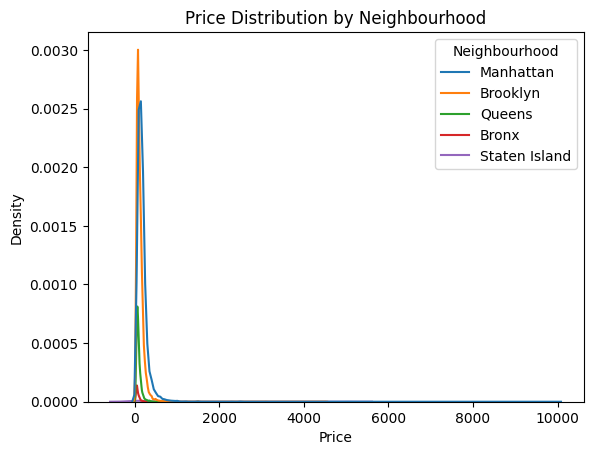

In [20]:
sns.kdeplot(data=df, x="Price", hue="Neighbourhood")
plt.title("Price Distribution by Neighbourhood")
plt.show()

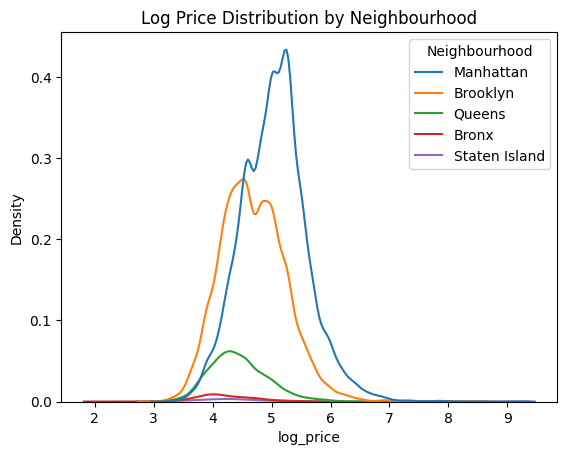

In [21]:
df["log_price"] = np.log(df["Price"])

sns.kdeplot(data=df, x="log_price", hue="Neighbourhood")
plt.title("Log Price Distribution by Neighbourhood")
plt.show()

In [ ]:
# 2.2

import statsmodels.api as sm

df["price"] = pd.to_numeric(df["Price"], errors="coerce")

X = pd.get_dummies(df["Neighbourhood"], drop_first=True, dtype=int)
X = sm.add_constant(X)

y = df["price"]

valid = pd.concat([y, X], axis=1).dropna()
y = valid["price"]
X = valid.drop(columns="price")

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        22:01:42   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

I dropped one neighborhood dummy and kept the intercept, so the intercept represents the average price for Bronx, which I omitted. Each neighborhood coefficient shows how much that borough’s average price differs from the Bronx average. This means the conditional group means from part 1 can be recovered by adding each dummy coefficient to the intercept. So the regression coefficients are just a re-expression of the group means using Bronx as the reference category.

In [ ]:
# 2.3

df["price"] = pd.to_numeric(df["Price"], errors="coerce")
df["rating"] = pd.to_numeric(df["Review_Scores_Rating"], errors="coerce")

X = sm.add_constant(df["rating"])
y = df["price"]

valid = pd.concat([y, X], axis=1).dropna()
y = valid["price"]
X = valid.drop(columns="price")

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        22:02:19   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         60.8784     10.423      5.841      0.0

The coefficient on Review Scores Rating is about 1.02, meaning a one-point increase in rating is means roughly a $1 increase in price per night on average. So while better-rated listings do tend to cost more, the relationship is not strong

In [ ]:
# 2.4

df["price"] = pd.to_numeric(df["Price"], errors="coerce")
df["rating"] = pd.to_numeric(df["Review_Scores_Rating"], errors="coerce")

dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True, dtype=int)

X = pd.concat([df["rating"], dummies], axis=1)
X = sm.add_constant(X)

y = df["price"]

valid = pd.concat([y, X], axis=1).dropna()
y = valid["price"]
X = valid.drop(columns="price")

# run regression
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        16:40:16   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -23.8126     14.105     -1.688

The coefficient on Review Scores Rating increases from about 1.02 to 1.08 after adding neighbourhood controls. This means that once we account for differences across neighbourhoods, the  relationship between rating and price becomes slightly stronger. So, higher-rated listings in the same neighborhood are slightly more expensive than the model suggested. 

In [ ]:
# 2.5 

df["price"] = pd.to_numeric(df["Price"], errors="coerce")
df["rating"] = pd.to_numeric(df["Review_Scores_Rating"], errors="coerce")

dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True, dtype=int)

interactions = dummies.mul(df["rating"], axis=0)

X = pd.concat([df["rating"], dummies, interactions], axis=1)
X = sm.add_constant(X)

y = df["price"]

valid = pd.concat([y, X], axis=1).dropna()
y = valid["price"]
X = valid.drop(columns="price")

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:44:22   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            22.6384    110.171      0.205

The slopes are all similar except for Staten Island which shows a different, negative slope. This means that the effect of rating on price is fairly consistent across most neighborhoods, except for Staten Island. 

In [37]:
# 2.6
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

df["price"] = pd.to_numeric(df["Price"], errors="coerce")
df["rating"] = pd.to_numeric(df["Review_Scores_Rating"], errors="coerce")

df = df.dropna(subset=["price", "rating", "Neighbourhood"])

y = df["price"]

X3 = df[["rating"]]

dummies = pd.get_dummies(df["Neighbourhood"], drop_first=True)
X4 = pd.concat([df["rating"], dummies], axis=1)

interactions = dummies.mul(df["rating"], axis=0)
X5 = pd.concat([df["rating"], dummies, interactions], axis=1)

def compute_rmse(X, y):
    model = LinearRegression()
    scores = cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error")
    rmse = np.sqrt(-scores.mean())
    return rmse

rmse_3 = compute_rmse(X3, y)
rmse_4 = compute_rmse(X4, y)
rmse_5 = compute_rmse(X5, y)

print("Model 3 RMSE:", rmse_3)
print("Model 4 RMSE:", rmse_4)
print("Model 5 RMSE:", rmse_5)

Model 3 RMSE: 148.67020601405693
Model 4 RMSE: 145.30351827213994
Model 5 RMSE: 146.34974161388354


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0

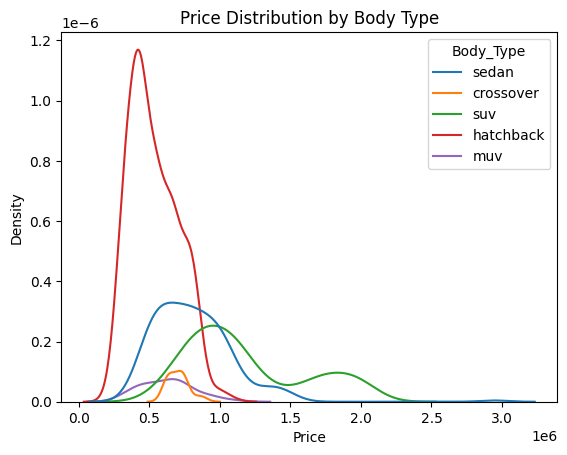

In [38]:
# 3.1 
df = pd.read_csv("cars_hw.csv")

print(df["Price"].describe())

group_summary = df.groupby("Body_Type")["Price"].describe()
print(group_summary)

# KDE
sns.kdeplot(data=df, x="Price", hue="Body_Type")
plt.title("Price Distribution by Body Type")
plt.show()

SUVs are the most expensive and have the most variance. 

In [40]:
# 3.2

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

df["Seating_Capacity"] = df["Seating_Capacity"].astype(str)

dummies = pd.get_dummies(df["Seating_Capacity"], drop_first=True, dtype=int)

X = sm.add_constant(dummies)
y = df["Price"]

valid = pd.concat([y, X], axis=1).dropna()
y = valid["Price"]
X = valid.drop(columns="Price")

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000267
Time:                        16:56:55   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.88e+05   3.64e+05      0.516      0.6

The differences in price are not roughly linear in the number of seats. If the relationship were linear, we would expect prices to increase steadily as seating capacity increases. However, the coefficients vary a lot. 

In [42]:
# 3.3 

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["Make_Year"] = pd.to_numeric(df["Make_Year"], errors="coerce")

df["Age"] = 2026 - df["Make_Year"]

df = df.dropna(subset=["Price", "Age"])

y = df["Price"]

def build_poly(age, degree):
    X = pd.DataFrame()
    for d in range(1, degree + 1):
        X[f"Age^{d}"] = age ** d
    return X

results = {}

for d in range(1, 6):
    X = build_poly(df["Age"], d)
    
    model = LinearRegression()
    scores = cross_val_score(model, X, y, cv=10, scoring="neg_mean_squared_error")
    
    rmse = np.sqrt(-scores.mean())
    results[d] = rmse
    
    print(f"Degree {d} RMSE:", rmse)


best_degree = min(results, key=results.get)
print("Optimal number of powers of Age:", best_degree)

Degree 1 RMSE: 316694.4427669285
Degree 2 RMSE: 317513.1817679725
Degree 3 RMSE: 316828.28644538566
Degree 4 RMSE: 316977.01986281027
Degree 5 RMSE: 316435.37443221535
Optimal number of powers of Age: 5


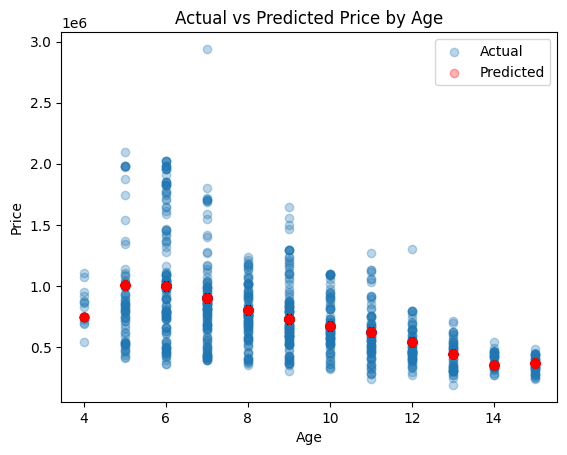

In [43]:
# 3.4 

X = build_poly(df["Age"], 5)

# fit model
model = LinearRegression().fit(X, y)

# predictions
df["predicted"] = model.predict(X)

# plot
plt.scatter(df["Age"], df["Price"], alpha=0.3, label="Actual")
plt.scatter(df["Age"], df["predicted"], color="red", alpha=0.3, label="Predicted")

plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Actual vs Predicted Price by Age")
plt.legend()
plt.show()

The model captures the general pattern that price decreases as age increases, but it does not fit the data perfectly. There is still a lot of variation in prices at each age that the model does not explain.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [44]:
df = pd.read_csv("heart_hw.csv")
print(df.head())
print(df.dtypes)

   Unnamed: 0  age transplant  y
0           1   53    control  0
1           2   43    control  0
2           3   52    control  0
3           4   52    control  0
4           5   54    control  0
Unnamed: 0     int64
age            int64
transplant    object
y              int64
dtype: object


In [45]:
# 4.1
control_survival = df[df["transplant"] == "control"]["y"].mean()
treatment_survival = df[df["transplant"] == "treatment"]["y"].mean()
ate = treatment_survival - control_survival

print("Control survival rate:", control_survival)
print("Treatment survival rate:", treatment_survival)
print("ATE:", ate)

Control survival rate: 0.11764705882352941
Treatment survival rate: 0.34782608695652173
ATE: 0.23017902813299232


In [ ]:
# 4.2
df["treat"] = (df["transplant"] == "treatment").astype(int)

X = sm.add_constant(df["treat"])
y = df["y"]

model2 = sm.OLS(y, X).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0133
Time:                        17:10:01   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1176      0.075      1.574      0.1

The intercept equals the control survival rate, and the transplant coefficient equals the ATE, so the regression results match the values from part 1.

In [47]:
# 4.3

X = sm.add_constant(df[["treat", "age"]])
y = df["y"]

model3 = sm.OLS(y, X).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000357
Time:                        17:13:36   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7020      0.196      3.583      0.0

The transplant coefficient increases slightly from about 0.23 to 0.26 after controlling for age, meaning the original estimate slightly underestimated the effect. The intercept is the predicted survival for the control group at age 0, and the age coefficient shows how survival changes as age increases.

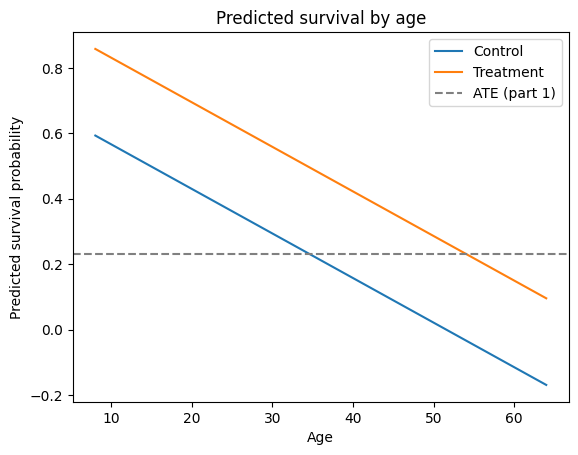

In [48]:
age_grid = np.linspace(df["age"].min(), df["age"].max(), 100)

pred_control = model3.predict(pd.DataFrame({
    "const": 1,
    "treat": 0,
    "age": age_grid
}))

pred_treat = model3.predict(pd.DataFrame({
    "const": 1,
    "treat": 1,
    "age": age_grid
}))

plt.plot(age_grid, pred_control, label="Control")
plt.plot(age_grid, pred_treat, label="Treatment")

plt.axhline(ate, linestyle="--", color="gray", label="ATE (part 1)")

plt.xlabel("Age")
plt.ylabel("Predicted survival probability")
plt.title("Predicted survival by age")
plt.legend()
plt.show()

The ATE roughly matches the true effect around age 50–55. It underestimates the effect for younger ages and overestimates it for older ages.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000310
Time:                        17:18:57   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3549      0.280      1.269      0.2

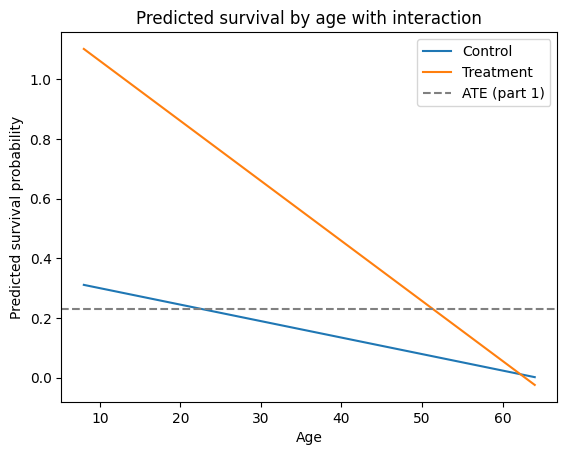

In [ ]:
# 4.4 
df["treat_age"] = df["treat"] * df["age"]

X = sm.add_constant(df[["treat", "age", "treat_age"]])
y = df["y"]

model4 = sm.OLS(y, X).fit()
print(model4.summary())

age_grid = np.linspace(df["age"].min(), df["age"].max(), 100)

pred_control = model4.predict(pd.DataFrame({
    "const": 1,
    "treat": 0,
    "age": age_grid,
    "treat_age": 0
}))

pred_treat = model4.predict(pd.DataFrame({
    "const": 1,
    "treat": 1,
    "age": age_grid,
    "treat_age": age_grid
}))

plt.plot(age_grid, pred_control, label="Control")
plt.plot(age_grid, pred_treat, label="Treatment")
plt.axhline(ate, linestyle="--", color="gray", label="ATE (part 1)")

plt.xlabel("Age")
plt.ylabel("Predicted survival probability")
plt.title("Predicted survival by age with interaction")
plt.legend()
plt.show()

Allowing age and transplant to interact makes the treatment and control lines no longer parallel. The gap is larger at younger ages and shrinks as age increases, meaning the benefit of a transplant decreases and is impacted with age.

In [52]:
# 4.5
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

kf = KFold(n_splits=10, shuffle=True, random_state=1)

y = df["y"]

# Model 1: treat only
X1 = df[["treat"]]

# Model 2: treat + age
X2 = df[["treat", "age"]]

# Model 3: treat + age + interaction
df["treat_age"] = df["treat"] * df["age"]
X3 = df[["treat", "age", "treat_age"]]

def cv_rmse(X, y):
    rmses = []
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model = LinearRegression().fit(X_train, y_train)
        preds = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(y_test, preds))
        rmses.append(rmse)
        
    return np.mean(rmses)

rmse1 = cv_rmse(X1, y)
rmse2 = cv_rmse(X2, y)
rmse3 = cv_rmse(X3, y)

print("Model 1 (treat only):", rmse1)
print("Model 2 (treat + age):", rmse2)
print("Model 3 (interaction):", rmse3)

Model 1 (treat only): 0.43712414924209
Model 2 (treat + age): 0.42099983660598966
Model 3 (interaction): 0.42010824697341576


Model 3 seems to be the one with the best predictive abilities. 

**4.6**

My main concern is that the model might be biased because the data isn’t random, so it may not show the true effect of a transplant. It also leaves out important factors like previous health conditions or status, so the predictions could be wrong. Using it to decide who gets a transplant could be unfair and risky, especially when people's lives are at risk. There needs o be further testing in order to actually deploy this model. 